In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mcbif import MultiscaleClusteringBifiltration as MCbiF
from sankey import Sankey

In [2]:
plt.rcParams.update({'font.size': 30})

# I) 3-Element Toy Example

Our first example is a sequence of 5 partitions defined on 3 elements each. This corresponds to Figure 1 in our paper: https://openreview.net/forum?id=E7D6uybODJ

In [3]:
# data for toy example
partitions = [[0, 1, 2], [0, 0, 1], [0, 1, 1], [0, 1, 0], [0, 0, 0]]
filtration_indices = [0, 1, 2, 3, 4]

In [4]:
# initialise Sankey
sankey = Sankey(partitions=partitions)

# optimise Sankey
sankey.compute_omics_sankey(stage1_iter=3000,stage2_iter=3000) 

OmicsSankey - Stage 1


100%|██████████| 3000/3000 [00:00<00:00, 3856.95it/s]


OmicsSankey - Stage 2


100%|██████████| 3000/3000 [00:00<00:00, 3478.71it/s]


In [5]:
# plot Sankey
fig = sankey.plot_sankey(pad=30,thickness=4)
fig.write_image(f"figures/mcbif_toy.svg")

Construct one-parameter filtration ...


100%|██████████| 5/5 [00:00<00:00, 3476.71it/s]


Construct two-parameter filtration ...


100%|██████████| 7/7 [00:00<00:00, 41645.57it/s]

Compute 0-dim MPH ...
Compute 1-dim MPH ...

Average 0-conflict: 0.25
Average 1-conflict: 0.2


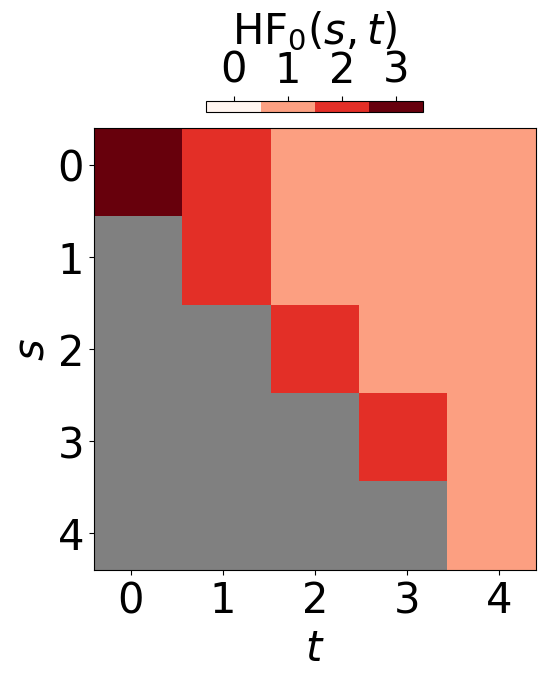

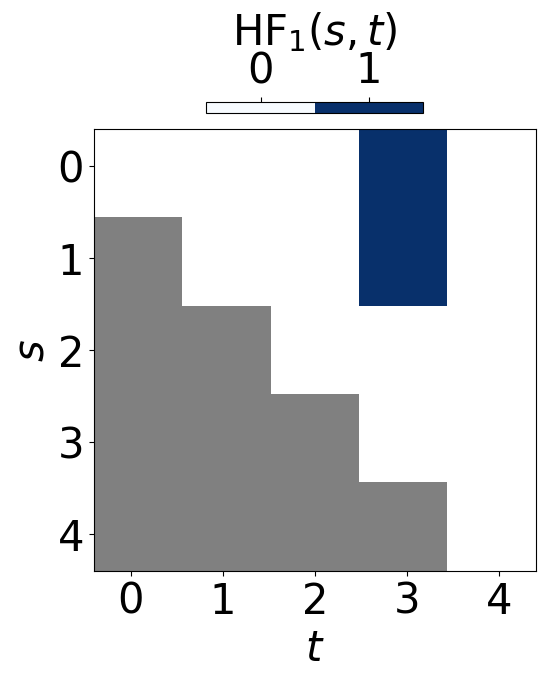

In [6]:
# compute MCbiF
mcbif = MCbiF(method="standard")
mcbif.load_data(partitions,filtration_indices)
mcbif_results = mcbif.compute_all_measures(file_path=None, landscape_resolution=-1)
print("\nAverage 0-conflict:", round(mcbif.conflict_0_avg,3))
print("Average 1-conflict:", round(mcbif.conflict_1_avg,3))

# plot Hilbert functions
mcbif.plot_hilbert_function(0, path="figures/mcbif_toy_hf0.svg", discrete_ticks=[0,1,2,3])
mcbif.plot_hilbert_function(1, path="figures/mcbif_toy_hf1.svg",discrete_ticks=[0,1]);

# II) 4-Element Toy Example

Our second example is a sequence of 10 partitions defined on 4 elements each. This corresponds to Example 38 / Figure 8 in the Appendix of our Paper.

In [7]:
# data for toy example
partitions = [[0, 1, 2, 3], [0, 0, 1, 2], [0, 1, 1, 2], [0, 1, 2, 2], [0, 1, 0, 2], [0, 1, 2, 0], [0, 1, 2, 1], [0,0,0,1],[0,1,1,1],[0,1,0,0]]
filtration_indices = np.arange(len(partitions))

In [8]:
# initialise Sankey
sankey = Sankey(partitions=partitions)

# optimise Sankey
sankey.compute_omics_sankey(stage1_iter=5000,stage2_iter=5000) 

OmicsSankey - Stage 1


100%|██████████| 5000/5000 [00:02<00:00, 1820.02it/s]


OmicsSankey - Stage 2


100%|██████████| 5000/5000 [00:04<00:00, 1205.86it/s]


In [9]:
# plot Sankey
fig = sankey.plot_sankey(pad=30,thickness=4)
fig.write_image(f"figures/mcbif_toy_4elements_sankey.svg")

Construct one-parameter filtration ...


100%|██████████| 10/10 [00:00<00:00, 9181.93it/s]


Construct two-parameter filtration ...


100%|██████████| 13/13 [00:00<00:00, 32591.72it/s]

Compute 0-dim MPH ...
Compute 1-dim MPH ...

Average 0-conflict: 0.511
Average 1-conflict: 0.733


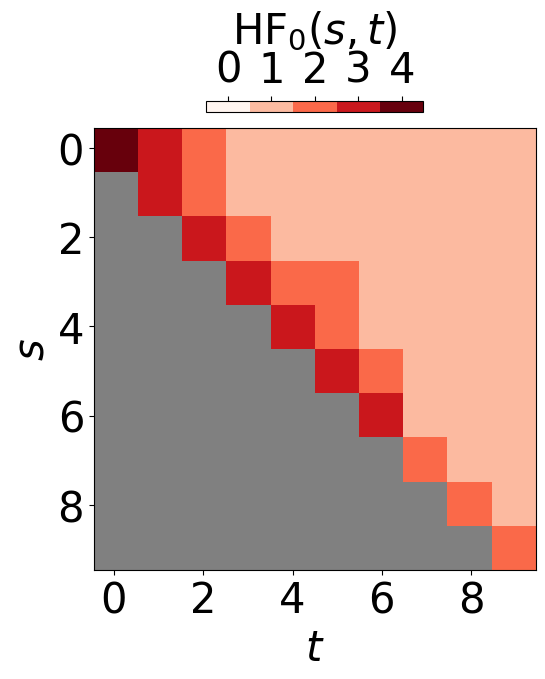

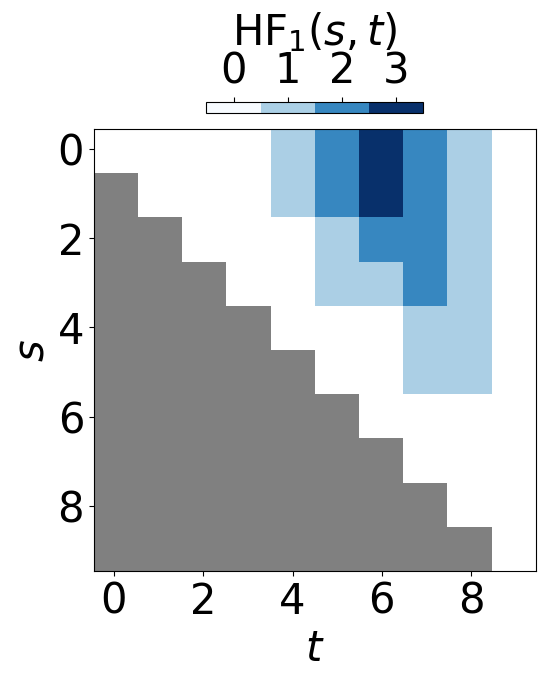

In [10]:
# compute MCbiF
mcbif = MCbiF(method="standard")
mcbif.load_data(partitions,filtration_indices)
mcbif_results = mcbif.compute_all_measures(file_path=None, landscape_resolution=-1)
print("\nAverage 0-conflict:", round(mcbif.conflict_0_avg,3))
print("Average 1-conflict:", round(mcbif.conflict_1_avg,3))

# plot Hilbert functions
mcbif.plot_hilbert_function(0, path="figures/mcbif_toy_4elements_hf0.svg", discrete_ticks=np.arange(5))
mcbif.plot_hilbert_function(1, path="figures/mcbif_toy_4elements_hf1.svg", discrete_ticks=np.arange(4));